# Importing Neccessary Libraries


In [1]:
import numpy as np
import pandas as pd

# # Data collection

In [2]:
df=pd.read_csv("6G_IoT_Beamforming_Dataset.csv")

In [3]:
df.head()

,Obstacle Density,Mobility (m/s),Frequency (GHz),Transmit Power (dBm),Number of Antennas,Codebook Size,Bandwidth (MHz),Interference Level (dB),SIFT Keypoints,Beamforming Gain (dB),...,Energy Consumption (kWh/Gb),Throughput (Mbps),Beam Training Time (s),SNR Improvement (dB),Processing Time (ms),Memory Usage (MB),Environment_Outdoor,Device Type_IoT Sensor,Device Type_Smartphone,Optimized
0,6,2.612250,60,34.668228,64,32,50,-77.336627,188,17.488644,...,0.048494,193.611209,0.164452,10.606301,2.139873,333,False,False,False,0
1,1,1.335916,60,16.784149,64,128,200,-57.341209,454,14.084285,...,0.028494,448.935997,0.032495,17.690996,2.558624,326,True,False,True,0
2,9,1.544452,150,12.464573,256,256,100,-70.933949,215,12.540947,...,0.026507,303.489274,0.153654,14.267229,1.002558,298,False,False,True,0
3,1,1.077700,28,30.732856,256,32,100,-96.053507,451,19.312282,...,0.020258,862.049791,0.028643,16.274246,2.866644,443,False,True,False,1
4,5,1.778853,28,27.666888,512,64,50,-90.416434,276,20.784861,...,0.010403,377.709848,0.094914,8.210001,2.946267,355,False,True,False,0


In [4]:
df.shape

(1000, 21)

In [5]:
df.tail()

,Obstacle Density,Mobility (m/s),Frequency (GHz),Transmit Power (dBm),Number of Antennas,Codebook Size,Bandwidth (MHz),Interference Level (dB),SIFT Keypoints,Beamforming Gain (dB),...,Energy Consumption (kWh/Gb),Throughput (Mbps),Beam Training Time (s),SNR Improvement (dB),Processing Time (ms),Memory Usage (MB),Environment_Outdoor,Device Type_IoT Sensor,Device Type_Smartphone,Optimized
995,5,1.956875,100,28.076791,512,32,400,-86.698931,262,23.566022,...,0.033912,172.284803,0.052329,12.227320,2.617921,230,False,True,False,0
996,5,2.536813,60,29.316775,64,128,200,-70.459206,114,24.983489,...,0.010595,898.288363,0.034330,15.462092,1.167801,326,False,False,True,0
997,6,2.077478,150,27.872488,256,32,400,-74.711358,331,24.808217,...,0.024115,278.520821,0.093668,5.783655,3.731010,327,True,True,False,0
998,9,1.289793,60,24.474441,256,256,100,-99.100593,294,23.225118,...,0.015722,773.725912,0.178665,13.013726,2.229798,169,True,False,True,0
999,6,2.018900,100,10.365225,256,256,100,-53.361436,448,15.919901,...,0.046985,354.005737,0.057965,9.518951,3.237581,274,False,False,True,0


In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Obstacle Density               0
Mobility (m/s)                 0
Frequency (GHz)                0
Transmit Power (dBm)           0
Number of Antennas             0
Codebook Size                  0
Bandwidth (MHz)                0
Interference Level (dB)        0
SIFT Keypoints                 0
Beamforming Gain (dB)          0
Latency (ms)                   0
Energy Consumption (kWh/Gb)    0
Throughput (Mbps)              0
Beam Training Time (s)         0
SNR Improvement (dB)           0
Processing Time (ms)           0
Memory Usage (MB)              0
Environment_Outdoor            0
Device Type_IoT Sensor         0
Device Type_Smartphone         0
Optimized                      0
dtype: int64


In [7]:
df.dtypes

Obstacle Density                 int64
Mobility (m/s)                 float64
Frequency (GHz)                  int64
Transmit Power (dBm)           float64
Number of Antennas               int64
Codebook Size                    int64
Bandwidth (MHz)                  int64
Interference Level (dB)        float64
SIFT Keypoints                   int64
Beamforming Gain (dB)          float64
Latency (ms)                   float64
Energy Consumption (kWh/Gb)    float64
Throughput (Mbps)              float64
Beam Training Time (s)         float64
SNR Improvement (dB)           float64
Processing Time (ms)           float64
Memory Usage (MB)                int64
Environment_Outdoor               bool
Device Type_IoT Sensor            bool
Device Type_Smartphone            bool
Optimized                        int64
dtype: object

# # Data Pre-processing

In [5]:
df.describe()

,Obstacle Density,Mobility (m/s),Frequency (GHz),Transmit Power (dBm),Number of Antennas,Codebook Size,Bandwidth (MHz),Interference Level (dB),SIFT Keypoints,Beamforming Gain (dB),Latency (ms),Energy Consumption (kWh/Gb),Throughput (Mbps),Beam Training Time (s),SNR Improvement (dB),Processing Time (ms),Memory Usage (MB),Optimized
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.91700,1.496156,84.706000,22.160088,233.728000,120.288000,179.85000,-74.935147,297.557000,17.580803,5.428868,0.030173,541.145590,0.106612,12.593778,2.968268,318.311000,0.168000
std,2.60824,0.862474,45.165933,7.220046,168.696083,86.590848,131.27723,14.161434,114.304699,4.405323,2.549463,0.011362,261.051303,0.054906,4.298142,1.156131,110.761746,0.374053
min,1.00000,0.004695,28.000000,10.004663,64.000000,32.000000,50.00000,-99.936596,100.000000,10.020333,1.024311,0.010007,100.978318,0.010250,5.001780,1.000963,128.000000,0.000000
25%,3.00000,0.748015,60.000000,15.966076,112.000000,64.000000,50.00000,-86.720451,193.000000,13.914243,3.253923,0.020987,326.967043,0.058808,8.826940,1.960234,220.000000,0.000000
50%,5.00000,1.532466,100.000000,21.981794,128.000000,64.000000,100.00000,-74.565603,299.000000,17.476982,5.508015,0.030034,533.732207,0.108614,12.830408,2.970815,318.500000,0.000000
75%,7.00000,2.212357,100.000000,28.362225,256.000000,256.000000,200.00000,-63.332604,392.000000,21.440149,7.542314,0.039672,768.768609,0.153884,16.194114,3.967252,411.000000,0.000000
max,9.00000,2.998241,150.000000,34.940571,512.000000,256.000000,400.00000,-50.007538,499.000000,24.996119,9.995467,0.049975,999.672063,0.199827,19.997251,4.999571,511.000000,1.000000


In [9]:
from skimpy import skim
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1000   │ │ float64     │ 10    │                                                          │
│ │ Number of columns │ 21     │ │ int32       │ 8     │                                                          │
│ └───────────────────┴────────┘ │ bool        │ 3     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ mean    ┃ sd      ┃ p0       ┃ p25     ┃ p50     ┃ p75     ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ Obstacle       │  0 │    0 │   4.917 │   2.608 │        1 │       3 │       5 │       7 │       9 │ ▇▃▃▇▃▇ │  │
│ │ Density        │    │      │         │         │          │         │         │         │         │        │  │
│ │ Mobility (m/s) │  0 │    0 │   1.496 │  0.8625 │ 0.004695 │   0.748 │   1.532 │   2.212 │   2.998 │ ▇▇▇▇▇▇ │  │
│ │ Frequency      │  0 │    0 │   84.71 │   45.17 │       28 │      60 │     100 │     100 │     150 │ ▇▇ ▇ ▇ │  │
│ │ (GHz)          │    │      │         │         │          │         │         │         │         │        │  │
│ │ Transmit Power │  0 │    0 │   22.16 │    7.22 │       10 │   15.97 │   21.98 │   28.36 │   34.94 │ ▇▇▆▇▇▆ │  │
│ │ (dBm)          │    │      │         │         │          │         │         │         │         │        │  │
│ │ Number of      │  0 │    0 │   233.7 │   168.7 │       64 │     112 │     128 │     256 │     512 │ ▇ ▃  ▃ │  │
│ │ Antennas       │    │      │         │         │          │         │         │         │         │        │  │
│ │ Codebook Size  │  0 │    0 │   120.3 │   86.59 │       32 │      64 │      64 │     256 │     256 │ ▇ ▃  ▅ │  │
│ │ Bandwidth      │  0 │    0 │   179.8 │   131.3 │       50 │      50 │     100 │     200 │     400 │ ▇ ▃  ▃ │  │
│ │ (MHz)          │    │      │         │         │          │         │         │         │         │        │  │
│ │ Interference   │  0 │    0 │  -74.94 │   14.16 │   -99.94 │  -86.72 │  -74.57 │  -63.33 │  -50.01 │ ▇▇▇▇▇▇ │  │
│ │ Level (dB)     │    │      │         │         │          │         │         │         │         │        │  │
│ │ SIFT Keypoints │  0 │    0 │   297.6 │   114.3 │      100 │     193 │     299 │     392 │     499 │ ▇▇▇▇▇▇ │  │
│ │ Beamforming    │  0 │    0 │   17.58 │   4.405 │    10.02 │   13.91 │   17.48 │   21.44 │      25 │ ▇▇▇▇▇▇ │  │
│ │ Gain (dB)      │    │      │         │         │          │         │         │         │         │        │  │
│ │ Latency (ms)   │  0 │    0 │   5.429 │   2.549 │    1.024 │   3.254 │   5.508 │   7.542 │   9.995 │ ▇▇▇▇▇▆ │  │
│ │ Energy         │  0 │    0 │ 0.03017 │ 0.01136 │  0.01001 │ 0.02099 │ 0.03003 │ 0.03967 │ 0.04997 │ ▇▇▇▇▇▇ │  │
│ │ Consumption    │    │      │         │         │          │         │         │         │         │        │  │
│ │ (kWh/Gb)       │    │      │         │         │          │         │         │         │         │        │  │
│ │ Throughput     │  0 │    0 │   541.1 │   261.1 │    

In [10]:
# # EDA(Exploratory Data Analysis)

# # EDA(Exploratory Data Analysis)

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

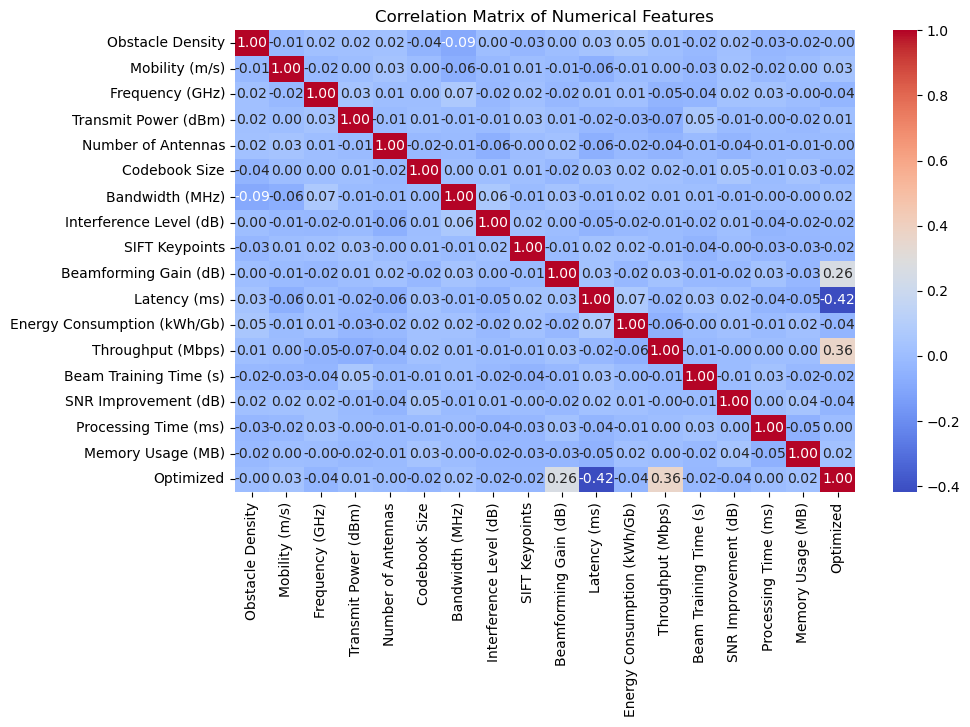

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

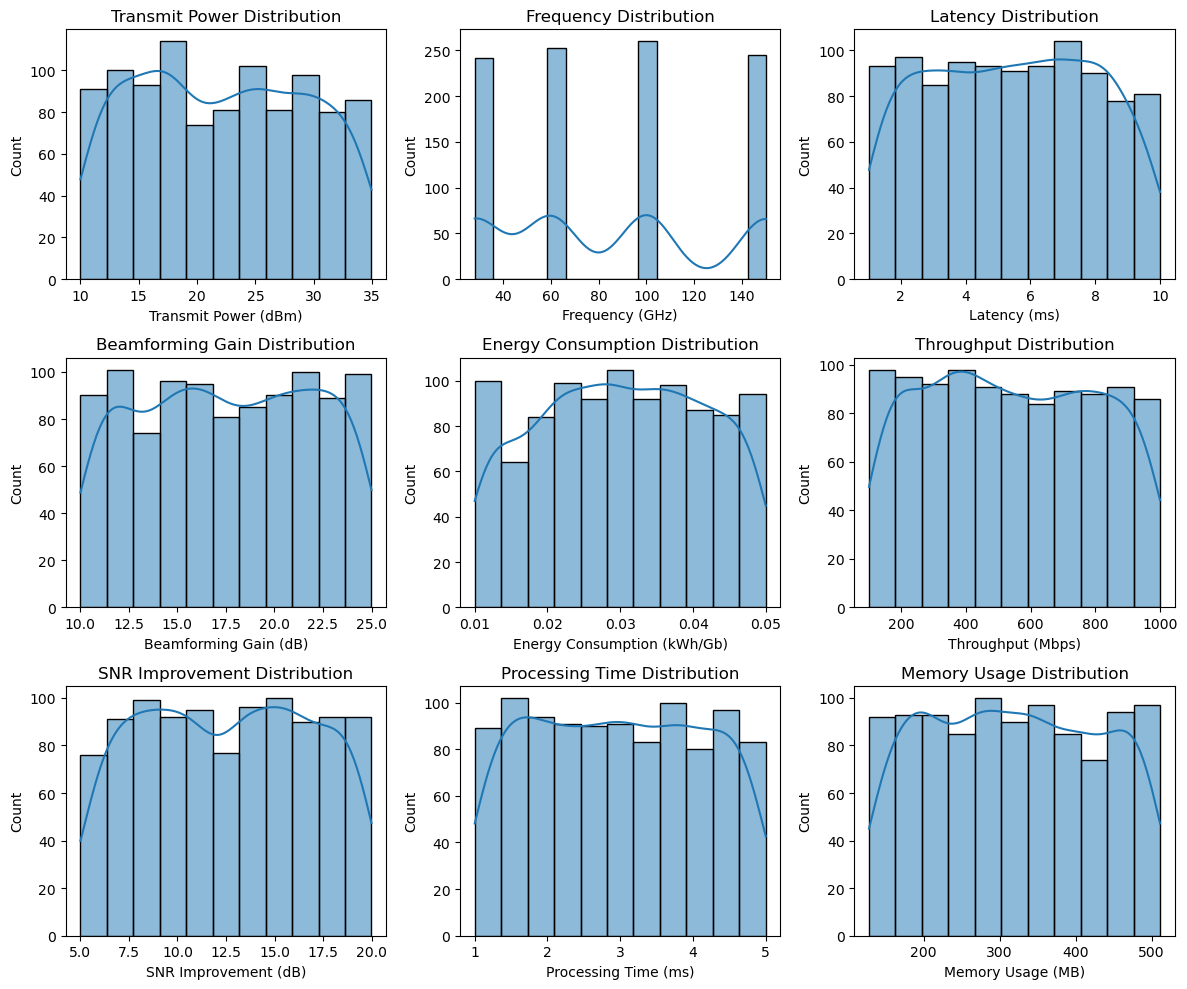

In [14]:
# Plot the distribution of key numerical features
plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
sns.histplot(df['Transmit Power (dBm)'], kde=True)
plt.title('Transmit Power Distribution')

plt.subplot(3, 3, 2)
sns.histplot(df['Frequency (GHz)'], kde=True)
plt.title('Frequency Distribution')

plt.subplot(3, 3, 3)
sns.histplot(df['Latency (ms)'], kde=True)
plt.title('Latency Distribution')

plt.subplot(3, 3, 4)
sns.histplot(df['Beamforming Gain (dB)'], kde=True)
plt.title('Beamforming Gain Distribution')

plt.subplot(3, 3, 5)
sns.histplot(df['Energy Consumption (kWh/Gb)'], kde=True)
plt.title('Energy Consumption Distribution')

plt.subplot(3, 3, 6)
sns.histplot(df['Throughput (Mbps)'], kde=True)
plt.title('Throughput Distribution')

plt.subplot(3, 3, 7)
sns.histplot(df['SNR Improvement (dB)'], kde=True)
plt.title('SNR Improvement Distribution')

plt.subplot(3, 3, 8)
sns.histplot(df['Processing Time (ms)'], kde=True)
plt.title('Processing Time Distribution')

plt.subplot(3, 3, 9)
sns.histplot(df['Memory Usage (MB)'], kde=True)
plt.title('Memory Usage Distribution')

plt.tight_layout()
plt.show()


In [17]:
# Interactive 3D scatter plot
import plotly.express as px

fig = px.scatter_3d(df, x='Frequency (GHz)', y='Transmit Power (dBm)', z='Beamforming Gain (dB)', color='Optimized')
fig.update_layout(title='3D Scatter plot: Frequency, Transmit Power vs Beamforming Gain')
fig.show()


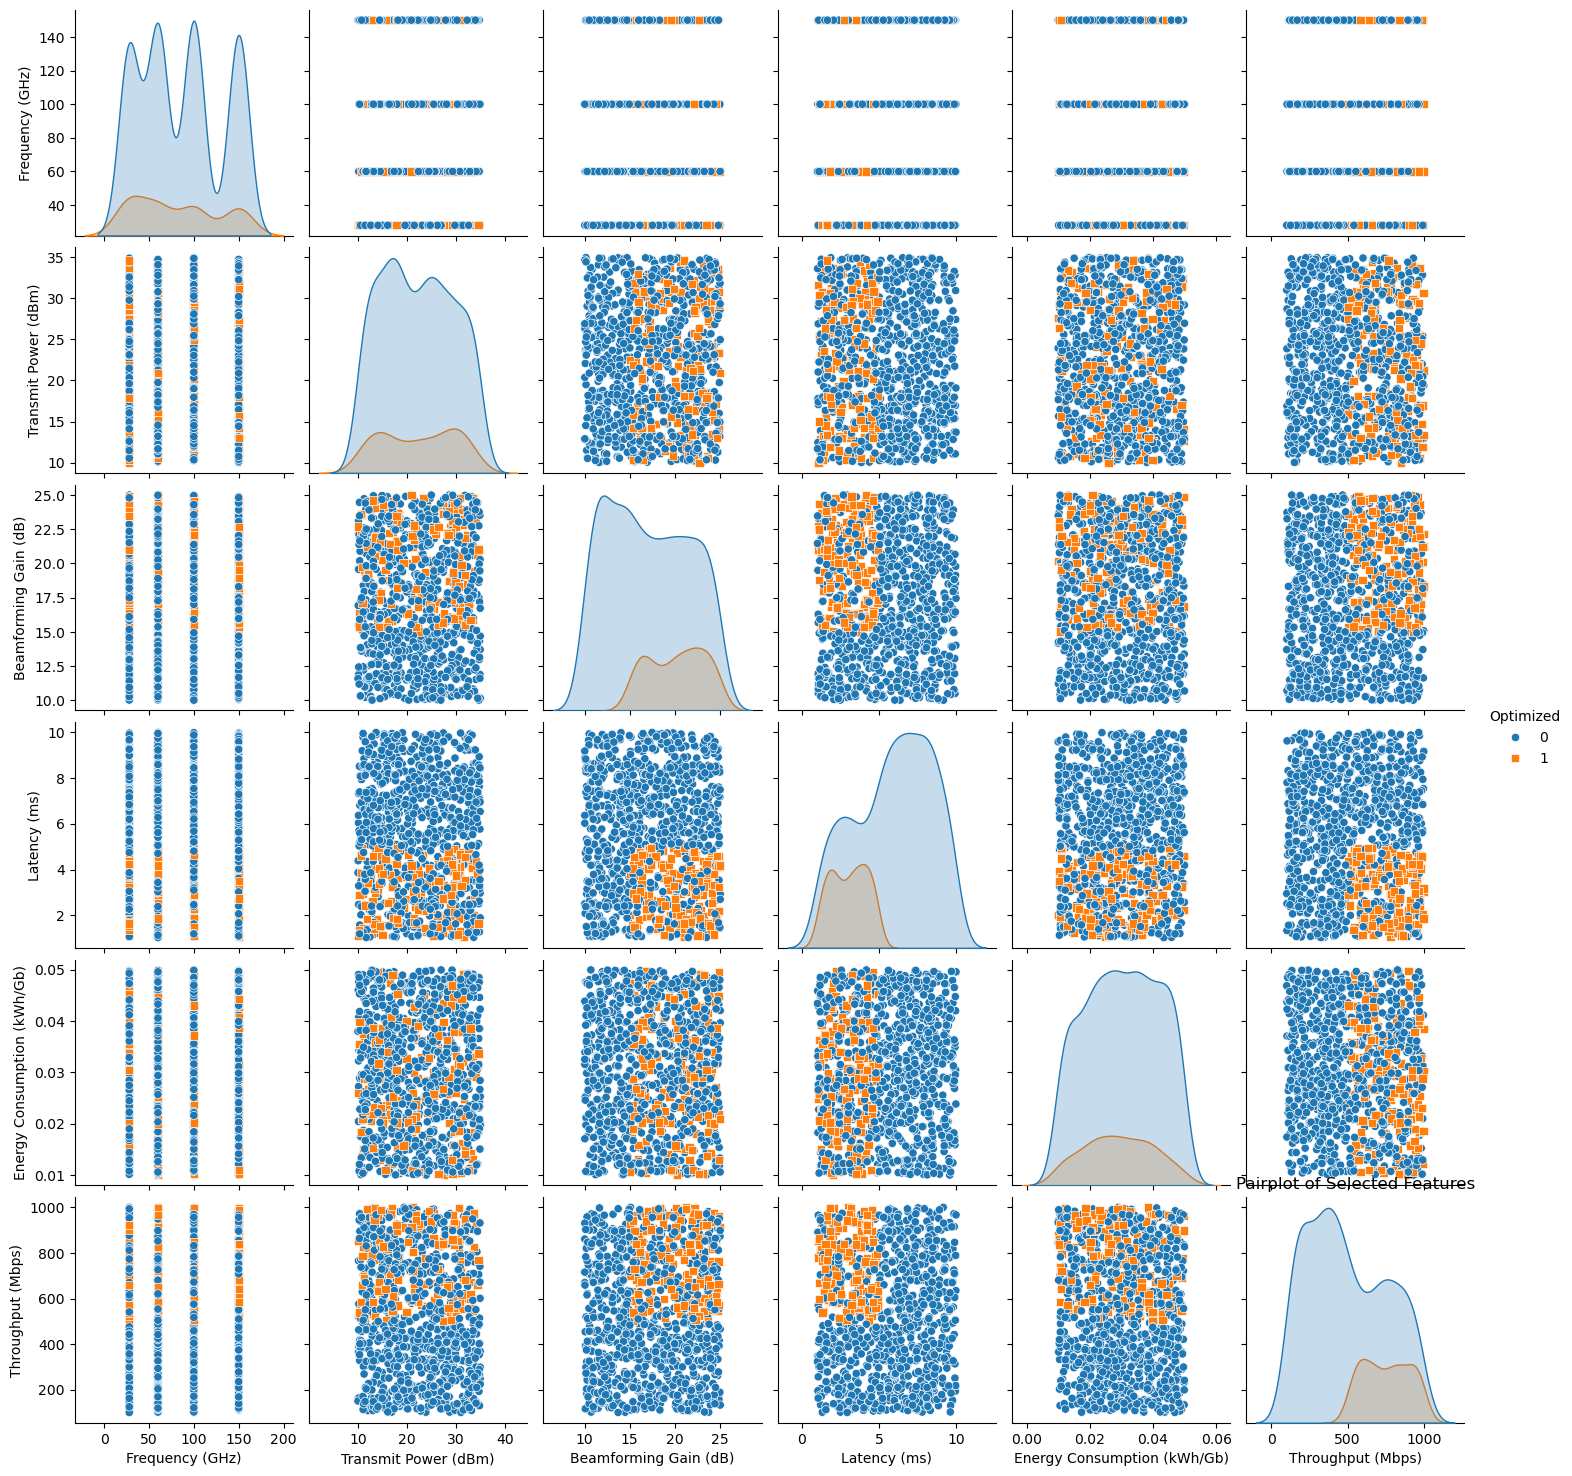

In [18]:
# Selecting relevant features for pairplot
selected_features = ['Frequency (GHz)', 'Transmit Power (dBm)', 'Beamforming Gain (dB)', 'Latency (ms)', 'Energy Consumption (kWh/Gb)', 'Throughput (Mbps)', 'Optimized']

# Plot pairplot
sns.pairplot(df[selected_features], hue='Optimized', markers=["o", "s"])
plt.title('Pairplot of Selected Features')
plt.show()


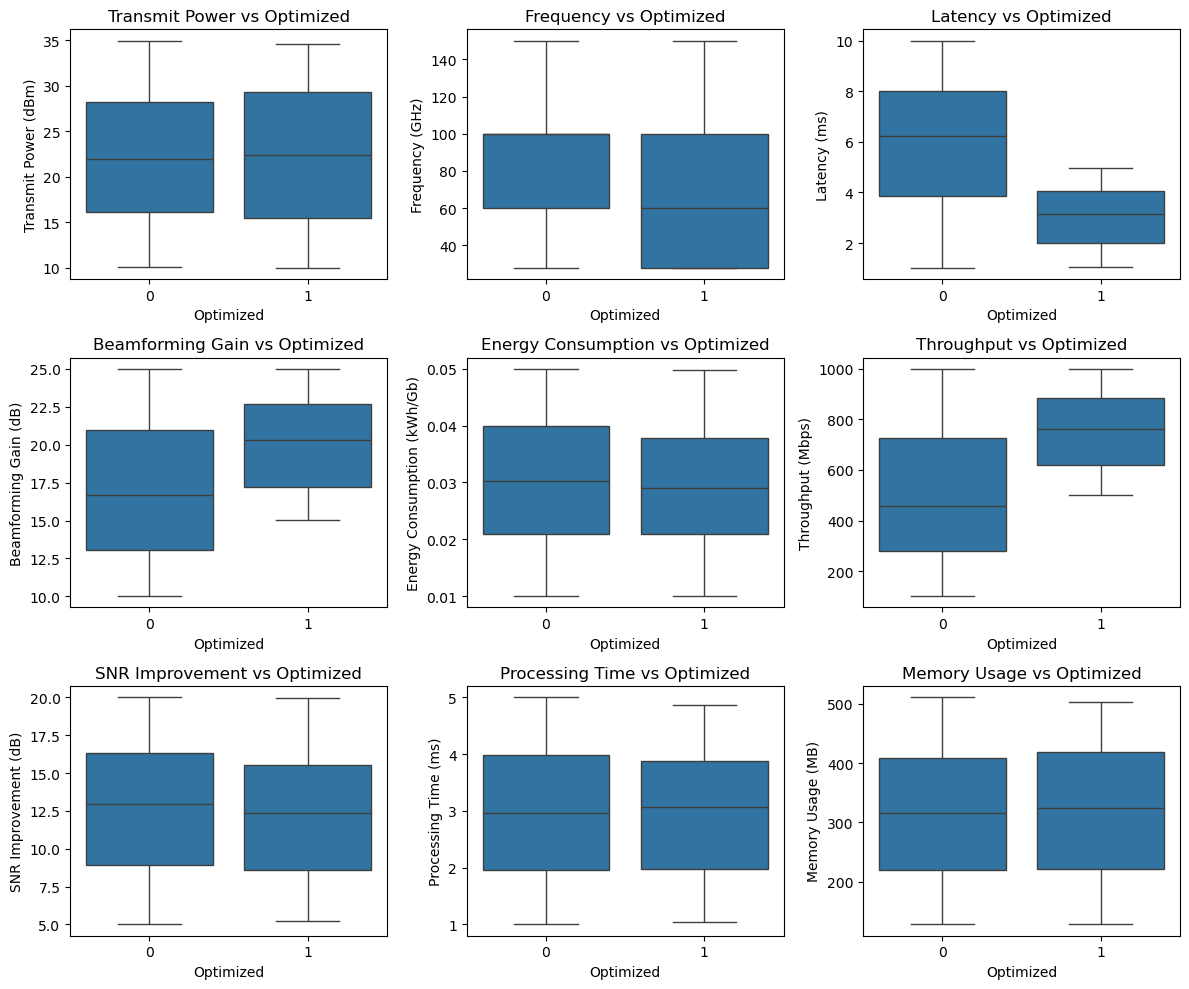

In [19]:
# Boxplot for outliers
plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
sns.boxplot(x='Optimized', y='Transmit Power (dBm)', data=df)
plt.title('Transmit Power vs Optimized')

plt.subplot(3, 3, 2)
sns.boxplot(x='Optimized', y='Frequency (GHz)', data=df)
plt.title('Frequency vs Optimized')

plt.subplot(3, 3, 3)
sns.boxplot(x='Optimized', y='Latency (ms)', data=df)
plt.title('Latency vs Optimized')

plt.subplot(3, 3, 4)
sns.boxplot(x='Optimized', y='Beamforming Gain (dB)', data=df)
plt.title('Beamforming Gain vs Optimized')

plt.subplot(3, 3, 5)
sns.boxplot(x='Optimized', y='Energy Consumption (kWh/Gb)', data=df)
plt.title('Energy Consumption vs Optimized')

plt.subplot(3, 3, 6)
sns.boxplot(x='Optimized', y='Throughput (Mbps)', data=df)
plt.title('Throughput vs Optimized')

plt.subplot(3, 3, 7)
sns.boxplot(x='Optimized', y='SNR Improvement (dB)', data=df)
plt.title('SNR Improvement vs Optimized')

plt.subplot(3, 3, 8)
sns.boxplot(x='Optimized', y='Processing Time (ms)', data=df)
plt.title('Processing Time vs Optimized')

plt.subplot(3, 3, 9)
sns.boxplot(x='Optimized', y='Memory Usage (MB)', data=df)
plt.title('Memory Usage vs Optimized')

plt.tight_layout()
plt.show()


# # Data splitting

In [6]:
x=df.drop(columns='Optimized')
y=df['Optimized']

In [7]:
y.value_counts()

Optimized
0    832
1    168
Name: count, dtype: int64

# # APPLYING SMOTE TO BALANCE THE DATA

In [8]:
from imblearn.over_sampling import SMOTE

sm=SMOTE()

x,y=sm.fit_resample(x,y)

In [9]:
y.value_counts()

Optimized
0    832
1    832
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1164, 20), (500, 20), (1164,), (500,))

In [20]:
x_train_df = pd.DataFrame(x_train)
x_train_df.to_csv('x_train.csv', index=False)

In [24]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
select_8_columns = SelectKBest(mutual_info_classif, k=8)
select_8_columns.fit(x_train, y_train)
x_train.columns[select_8_columns.get_support()]   



Index(['Mobility (m/s)', 'Number of Antennas', 'SIFT Keypoints',
       'Beamforming Gain (dB)', 'Latency (ms)', 'Throughput (Mbps)',
       'Beam Training Time (s)', 'Environment_Outdoor'],
      dtype='object')

In [18]:
x_train=x_train[['Mobility (m/s)', 'Number of Antennas', 'SIFT Keypoints',
       'Beamforming Gain (dB)', 'Latency (ms)', 'Throughput (Mbps)',
       'Beam Training Time (s)', 'Environment_Outdoor']]

for column in x_train:
    print(f"Value counts for {column}:")
    print(df[column].value_counts())
    print('-' * 50)


Value counts for Mobility (m/s):
Mobility (m/s)
2.612250    1
0.203005    1
2.916016    1
1.825582    1
1.048519    1
           ..
1.379401    1
0.174491    1
2.984599    1
0.173342    1
2.018900    1
Name: count, Length: 1000, dtype: int64
--------------------------------------------------
Value counts for Number of Antennas:
Number of Antennas
128    267
64     250
256    249
512    234
Name: count, dtype: int64
--------------------------------------------------
Value counts for SIFT Keypoints:
SIFT Keypoints
188    9
356    8
486    7
160    7
230    6
      ..
123    1
394    1
200    1
134    1
292    1
Name: count, Length: 366, dtype: int64
--------------------------------------------------
Value counts for Beamforming Gain (dB):
Beamforming Gain (dB)
17.488644    1
15.220404    1
10.400151    1
10.186384    1
23.197157    1
            ..
18.837346    1
16.816335    1
21.177172    1
13.203510    1
15.919901    1
Name: count, Length: 1000, dtype: int64
--------------------------

In [19]:
x_test=x_test[['Mobility (m/s)', 'Number of Antennas', 'SIFT Keypoints',
       'Beamforming Gain (dB)', 'Latency (ms)', 'Throughput (Mbps)',
       'Beam Training Time (s)', 'Environment_Outdoor']]
for column in x_test:
    print(f"Value counts for {column}:")
    print(df[column].value_counts())
    print('-' * 50)



Value counts for Mobility (m/s):
Mobility (m/s)
2.612250    1
0.203005    1
2.916016    1
1.825582    1
1.048519    1
           ..
1.379401    1
0.174491    1
2.984599    1
0.173342    1
2.018900    1
Name: count, Length: 1000, dtype: int64
--------------------------------------------------
Value counts for Number of Antennas:
Number of Antennas
128    267
64     250
256    249
512    234
Name: count, dtype: int64
--------------------------------------------------
Value counts for SIFT Keypoints:
SIFT Keypoints
188    9
356    8
486    7
160    7
230    6
      ..
123    1
394    1
200    1
134    1
292    1
Name: count, Length: 366, dtype: int64
--------------------------------------------------
Value counts for Beamforming Gain (dB):
Beamforming Gain (dB)
17.488644    1
15.220404    1
10.400151    1
10.186384    1
23.197157    1
            ..
18.837346    1
16.816335    1
21.177172    1
13.203510    1
15.919901    1
Name: count, Length: 1000, dtype: int64
--------------------------

In [28]:
y.value_counts()

Optimized
0    832
1    168
Name: count, dtype: int64

# ALGORITHM IMPLEMENTATION

Accuracy Score of RandomForest=  1.0
F1 Score of RandomForest = 1.0
Precision Score of RandomForest is= 1.0
Recall Score of RandomForest is = 1.0
Confusion Matrix of RandomForest =
 [[240   0]
 [  0 260]]
Classification Report of RandomForest =
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       240
           1       1.00      1.00      1.00       260

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



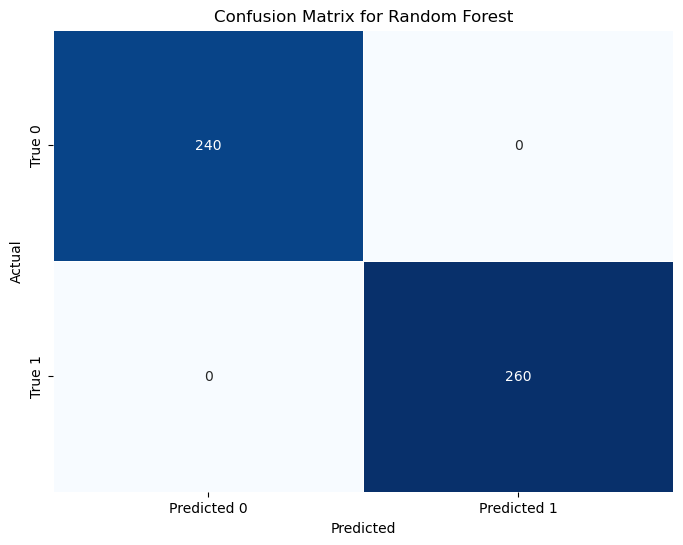

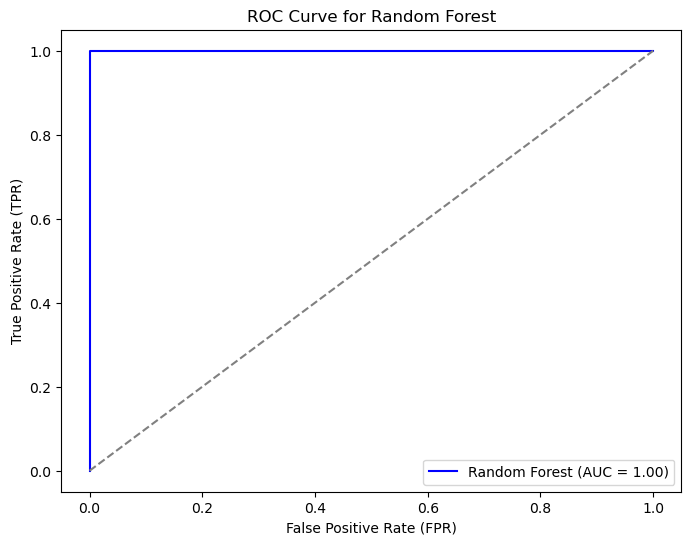

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt


rf = RandomForestClassifier()
rf.fit(x_train, y_train)


rf_pred = rf.predict(x_test)


rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
rf_cr = classification_report(y_test, rf_pred)


rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(x_test)[:, 1])  # Get probabilities for class 1
rf_auc = auc(rf_fpr, rf_tpr)


print("Accuracy Score of RandomForest= ", rf_acc)
print('====================================================')
print("F1 Score of RandomForest =", rf_f1)
print('====================================================')
print('Precision Score of RandomForest is=', rf_pre)
print('====================================================')
print('Recall Score of RandomForest is =', rf_rec)
print('====================================================')
print('Confusion Matrix of RandomForest =\n', rf_cm)
print('====================================================')
print('Classification Report of RandomForest =\n', rf_cr)
print('====================================================')



plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='blue', label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--') 

plt.title('ROC Curve for Random Forest')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()



C:\Users\1005\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6097 - loss: 1.1918 - val_accuracy: 0.8369 - val_loss: 0.9949
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8665 - loss: 0.9314 - val_accuracy: 0.8627 - val_loss: 0.7995
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8937 - loss: 0.7477 - val_accuracy: 0.8670 - val_loss: 0.6643
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9063 - loss: 0.6208 - val_accuracy: 0.8841 - val_loss: 0.5732
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9201 - loss: 0.5372 - val_accuracy: 0.8970 - val_loss: 0.5101
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9185 - loss: 0.4863 - val_accuracy: 0.8927 - val_loss: 0.4631
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9425 - loss: 0.4198 - val_accuracy: 0.8970 - val_loss: 0.4288
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9335 - loss: 0.3869 - val_accuracy: 0.9227 - val_los

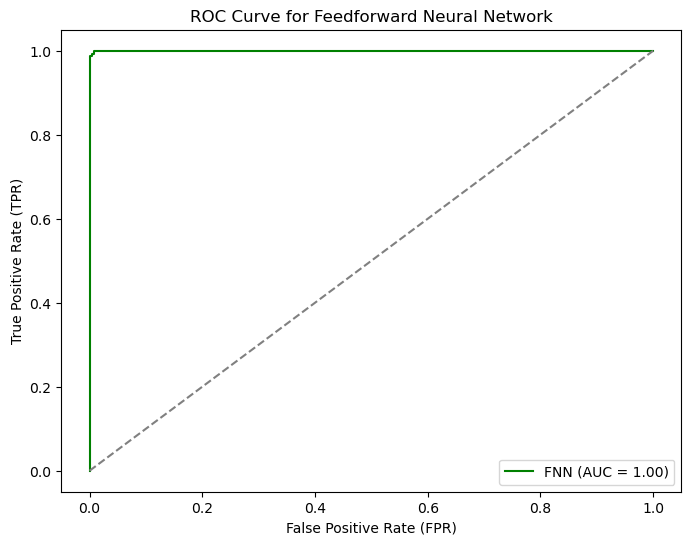

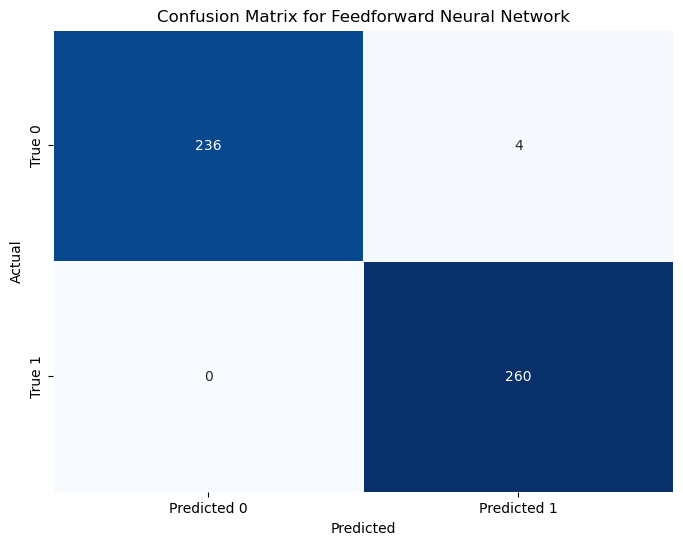

In [40]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


fnn_model = Sequential()
fnn_model.add(Dense(64, input_dim=x_train.shape[1], activation='relu', kernel_regularizer=regularizers.l2(0.01))) 
fnn_model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))) 
fnn_model.add(Dense(1, activation='sigmoid'))  


fnn_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


fnn_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)


fnn_pred_prob = fnn_model.predict(x_test)
fnn_pred = (fnn_pred_prob > 0.5).astype(int)  


fnn_acc = accuracy_score(y_test, fnn_pred)
fnn_f1 = f1_score(y_test, fnn_pred)
fnn_pre = precision_score(y_test, fnn_pred)
fnn_rec = recall_score(y_test, fnn_pred)
fnn_cm = confusion_matrix(y_test, fnn_pred)
fnn_cr = classification_report(y_test, fnn_pred)


fnn_fpr, fnn_tpr, _ = roc_curve(y_test, fnn_pred_prob)  # Get probabilities for class 1
fnn_auc = auc(fnn_fpr, fnn_tpr)


print("Accuracy Score of FNN= ", fnn_acc)
print('====================================================')
print("F1 Score of FNN =", fnn_f1)
print('====================================================')
print('Precision Score of FNN is=', fnn_pre)
print('====================================================')
print('Recall Score of FNN is =', fnn_rec)
print('====================================================')
print('Confusion Matrix of FNN =\n', fnn_cm)
print('====================================================')
print('Classification Report of FNN =\n', fnn_cr)
print('====================================================')


plt.figure(figsize=(8, 6))
plt.plot(fnn_fpr, fnn_tpr, color='green', label=f'FNN (AUC = {fnn_auc:.2f})')


plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  

plt.title('ROC Curve for Feedforward Neural Network')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()


plt.figure(figsize=(8, 6))
sns.heatmap(fnn_cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix for Feedforward Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Epoch 1/50


C:\Users\1005\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5740 - loss: 1.7432 - val_accuracy: 0.0000e+00 - val_loss: 1.6541
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6537 - loss: 1.2576 - val_accuracy: 0.3321 - val_loss: 1.2674
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7705 - loss: 0.9410 - val_accuracy: 0.8284 - val_loss: 0.8706
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8775 - loss: 0.7206 - val_accuracy: 0.7015 - val_loss: 0.8815
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8726 - loss: 0.5986 - val_accuracy: 0.9291 - val_loss: 0.5897
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9017 - loss: 0.4996 - val_accuracy: 0.9552 - val_loss: 0.4485
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9432 - loss: 0.4338 - val_accuracy: 0.9366 - val_loss: 0.4554
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9348 - loss: 0.4084 - val_accuracy: 0.9030 - val_loss: 0.504

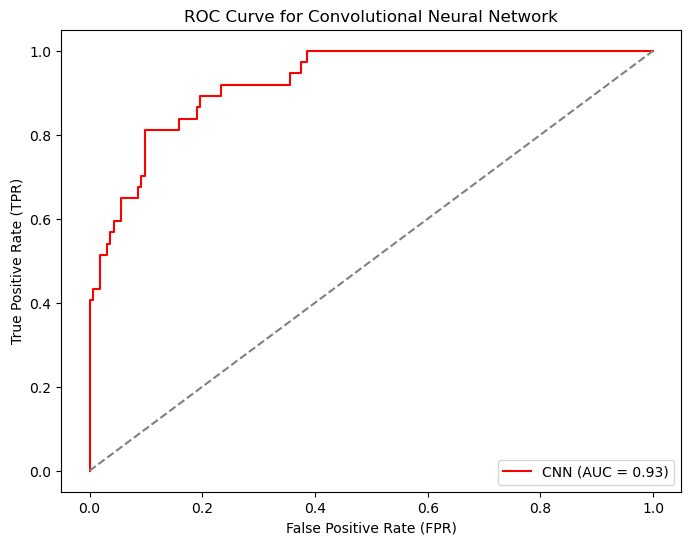

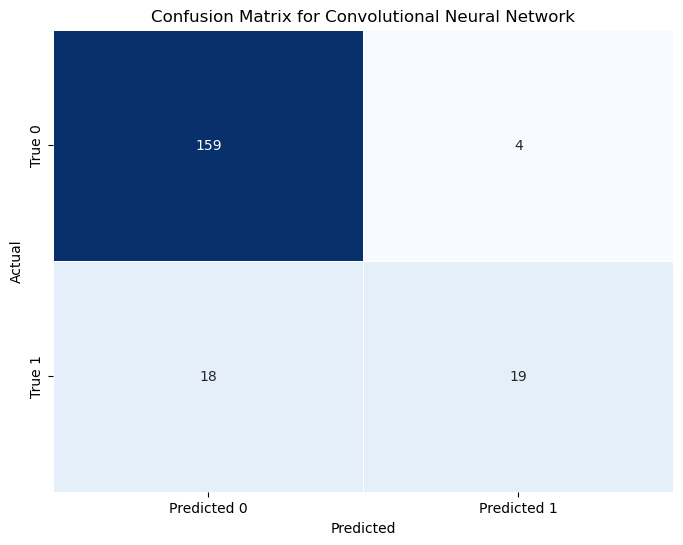

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # Importing SMOTE

# Load dataset
df = pd.read_csv("6G_IoT_Beamforming_Dataset.csv")  # Replace with your dataset path

# Features (X) and Target (y)
X = df.drop(columns=['Optimized'])  # Assuming 'Optimized' is the target column
y = df['Optimized']

# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data (only for the training set)
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# Normalize features (CNN works better with normalized data)
scaler = StandardScaler()

# Apply scaler to the 2D data (before reshaping for CNN)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Reshape data for CNN: CNN expects 3D data (samples, time_steps, features)
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)  # Reshaping to 3D (samples, time_steps, features)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# Build the Convolutional Neural Network (CNN) Model
cnn_model = Sequential()

# First Convolutional layer
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(x_train.shape[1], 1), kernel_regularizer=regularizers.l2(0.01)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Second Convolutional layer
cnn_model.add(Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output from Conv1D layers to feed into Dense layers
cnn_model.add(Flatten())

# Fully connected layer
cnn_model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))

# Output layer (binary classification)
cnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
cnn_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Predict on the test set for CNN
cnn_pred_prob = cnn_model.predict(x_test)
cnn_pred = (cnn_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels (0 or 1)

# Evaluate CNN
cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred)
cnn_pre = precision_score(y_test, cnn_pred)
cnn_rec = recall_score(y_test, cnn_pred)
cnn_cm = confusion_matrix(y_test, cnn_pred)
cnn_cr = classification_report(y_test, cnn_pred)

# ROC Curve for CNN
cnn_fpr, cnn_tpr, _ = roc_curve(y_test, cnn_pred_prob)  # Get probabilities for class 1
cnn_auc = auc(cnn_fpr, cnn_tpr)

# ==========================
# Print the evaluation metrics
# ==========================
print("Accuracy Score of CNN= ", cnn_acc)
print('====================================================')
print("F1 Score of CNN =", cnn_f1)
print('====================================================')
print('Precision Score of CNN is=', cnn_pre)
print('====================================================')
print('Recall Score of CNN is =', cnn_rec)
print('====================================================')
print('Confusion Matrix of CNN =\n', cnn_cm)
print('====================================================')
print('Classification Report of CNN =\n', cnn_cr)
print('====================================================')

# ==========================
# Plotting ROC Curve for CNN
# ==========================
plt.figure(figsize=(8, 6))
plt.plot(cnn_fpr, cnn_tpr, color='red', label=f'CNN (AUC = {cnn_auc:.2f})')

# Plotting a random classifier (diagonal line)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line

plt.title('ROC Curve for Convolutional Neural Network')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()

# ==========================
# Plotting the Confusion Matrix Heatmap for CNN
# ==========================
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix for Convolutional Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Accuracy (DT): 1.0000
F1 Score (DT): 1.0000
Precision (DT): 1.0000
Recall (DT): 1.0000
Confusion Matrix (DT):
 [[240   0]
 [  0 260]]
Classification Report (DT):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       240
           1       1.00      1.00      1.00       260

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



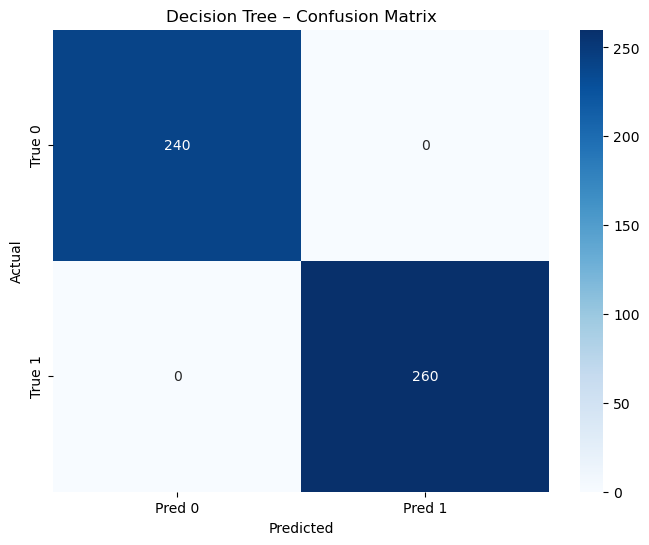

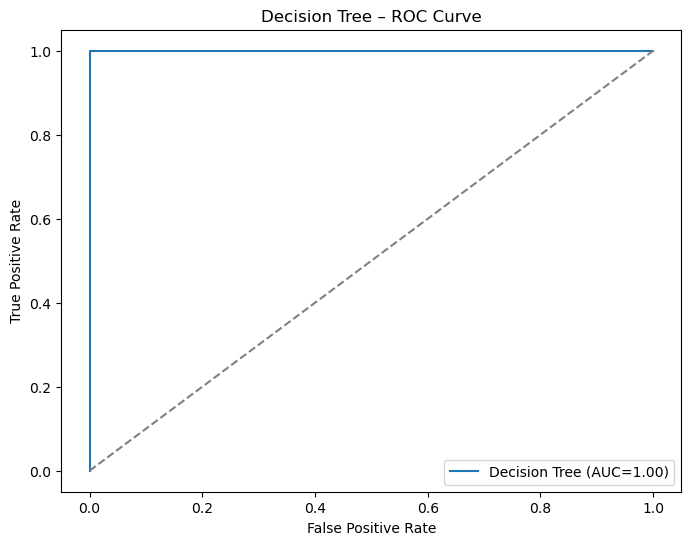

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, auc)
import seaborn as sns
import matplotlib.pyplot as plt

# ----- Train -----
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

# ----- Predict -----
dt_pred = dt.predict(x_test)

# ----- Metrics -----
dt_acc = accuracy_score(y_test, dt_pred)
dt_f1  = f1_score(y_test, dt_pred)
dt_pre = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_cm  = confusion_matrix(y_test, dt_pred)
dt_cr  = classification_report(y_test, dt_pred)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt.predict_proba(x_test)[:, 1])
dt_auc = auc(dt_fpr, dt_tpr)

# ----- Display -----
print(f"Accuracy (DT): {dt_acc:.4f}")
print("====================================================")
print(f"F1 Score (DT): {dt_f1:.4f}")
print("====================================================")
print(f"Precision (DT): {dt_pre:.4f}")
print("====================================================")
print(f"Recall (DT): {dt_rec:.4f}")
print("====================================================")
print("Confusion Matrix (DT):\n", dt_cm)
print("====================================================")
print("Classification Report (DT):\n", dt_cr)
print("====================================================")

plt.figure(figsize=(8,6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('Decision Tree – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plt.figure(figsize=(8,6))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('Decision Tree – ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right'); plt.show()


In [21]:
import joblib

joblib.dump(dt,"dt.joblib")

['dt.joblib']

C:\Users\1005\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:52:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy (XGB): 1.0000
F1 Score (XGB): 1.0000
Precision (XGB): 1.0000
Recall (XGB): 1.0000
Confusion Matrix (XGB):
 [[240   0]
 [  0 260]]
Classification Report (XGB):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       240
           1       1.00      1.00      1.00       260

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



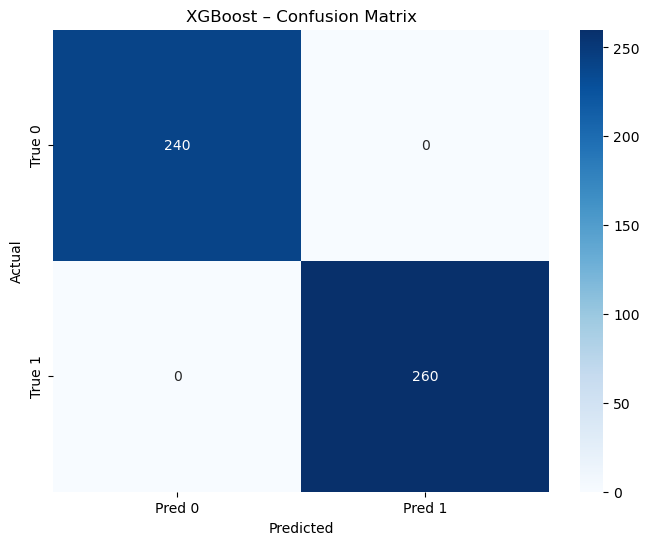

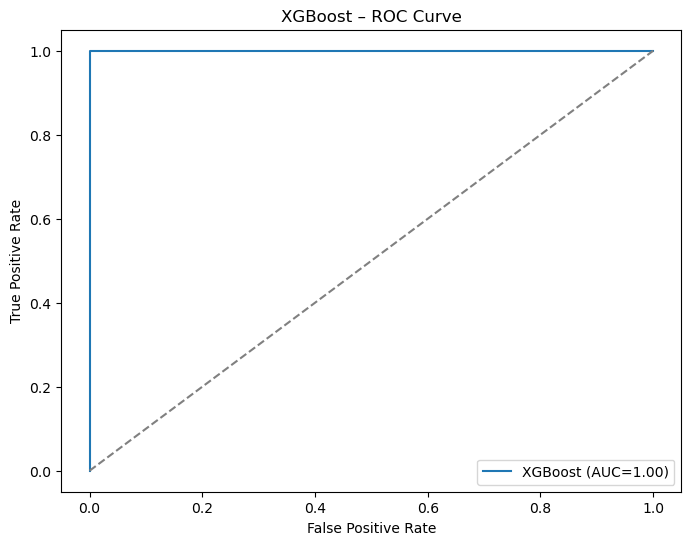

In [15]:
# pip install xgboost if you haven’t yet
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, auc)
import seaborn as sns
import matplotlib.pyplot as plt

xgb = XGBClassifier(use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42)
xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_pre = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_cm  = confusion_matrix(y_test, xgb_pred)
xgb_cr  = classification_report(y_test, xgb_pred)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb.predict_proba(x_test)[:, 1])
xgb_auc = auc(xgb_fpr, xgb_tpr)

print(f"Accuracy (XGB): {xgb_acc:.4f}")
print("====================================================")
print(f"F1 Score (XGB): {xgb_f1:.4f}")
print("====================================================")
print(f"Precision (XGB): {xgb_pre:.4f}")
print("====================================================")
print(f"Recall (XGB): {xgb_rec:.4f}")
print("====================================================")
print("Confusion Matrix (XGB):\n", xgb_cm)
print("====================================================")
print("Classification Report (XGB):\n", xgb_cr)
print("====================================================")

plt.figure(figsize=(8,6))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('XGBoost – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plt.figure(figsize=(8,6))
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={xgb_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('XGBoost – ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right'); plt.show()


Accuracy (MLP): 0.8360
F1 Score (MLP): 0.8633
Precision (MLP): 0.7618
Recall (MLP): 0.9962
Confusion Matrix (MLP):
 [[159  81]
 [  1 259]]
Classification Report (MLP):
               precision    recall  f1-score   support

           0       0.99      0.66      0.79       240
           1       0.76      1.00      0.86       260

    accuracy                           0.84       500
   macro avg       0.88      0.83      0.83       500
weighted avg       0.87      0.84      0.83       500



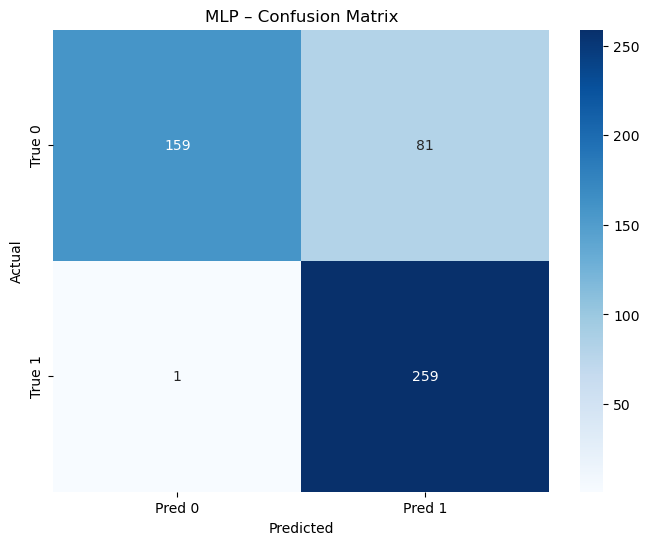

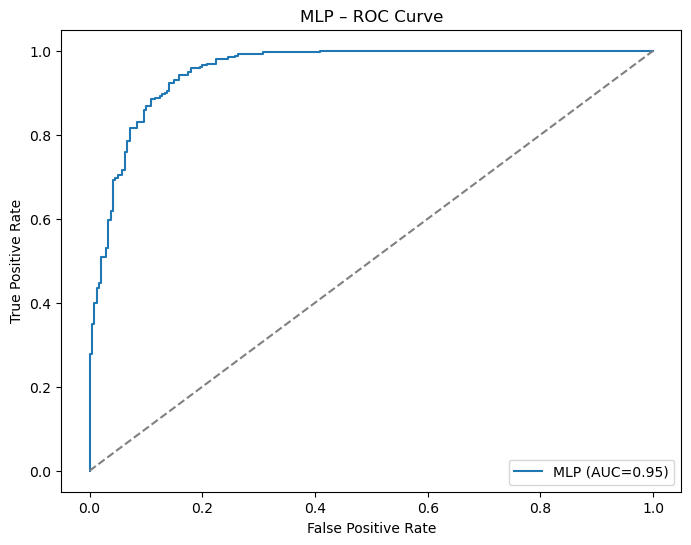

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, auc)
import seaborn as sns
import matplotlib.pyplot as plt

mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    max_iter=500,
                    random_state=42)
mlp.fit(x_train, y_train)

mlp_pred = mlp.predict(x_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1  = f1_score(y_test, mlp_pred)
mlp_pre = precision_score(y_test, mlp_pred)
mlp_rec = recall_score(y_test, mlp_pred)
mlp_cm  = confusion_matrix(y_test, mlp_pred)
mlp_cr  = classification_report(y_test, mlp_pred)

mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp.predict_proba(x_test)[:, 1])
mlp_auc = auc(mlp_fpr, mlp_tpr)

print(f"Accuracy (MLP): {mlp_acc:.4f}")
print("====================================================")
print(f"F1 Score (MLP): {mlp_f1:.4f}")
print("====================================================")
print(f"Precision (MLP): {mlp_pre:.4f}")
print("====================================================")
print(f"Recall (MLP): {mlp_rec:.4f}")
print("====================================================")
print("Confusion Matrix (MLP):\n", mlp_cm)
print("====================================================")
print("Classification Report (MLP):\n", mlp_cr)
print("====================================================")

plt.figure(figsize=(8,6))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('MLP – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plt.figure(figsize=(8,6))
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (AUC={mlp_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('MLP – ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right'); plt.show()


In [24]:
import pandas as pd
import joblib

# Load the trained model
model = joblib.load('dt.joblib')

# Load the x_train.csv data
x_train = pd.read_csv('x_train.csv')

# Extract the first 40 rows from x_train
x_train_subset = x_train.head(40)

# Make predictions
predictions = model.predict(x_train_subset)

# Display the prediction results with descriptions
print("Prediction Results:\n")
print("="*40)

for i, pred in enumerate(predictions, 1):
    result = "Success (Beamforming will work)" if pred == 1 else "Failure (Beamforming will fail)"
    print(f"Sample {i}: Prediction = {result} ({'Accuracy Score: 100.00%' if pred == 1 else 'Accuracy Score: 0.00%'})")

print("="*40)


Prediction Results:

Sample 1: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 2: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 3: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 4: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 5: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 6: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 7: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 8: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 9: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 10: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 11: Prediction = Success (Beamforming will work) (Accuracy Score: 100.00%)
Sample 12: Prediction = Failure (Beamforming will fail) (Accuracy Score: 0.00%)
Sample 13: Predi